# Replication of reskilling analysis from MSc thesis
Felix Zaussinger | 15.09.2022

**Core Analysis Goal(s)**
1. Replicate thesis approach based on updated data
2. Decide how to deal with skewed distribution when working with COOC matrix compared to ESCO matrix tables or Kanders Matrix
3. Understand and write down all of the assumptions that I make and reflect whether they are robust enough

**Key Insight(s)**
1. Replication based on ESCO v.1.1 is working!
2.
3.

In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from tqdm import tqdm
from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt

# load paths
from src import utils
from src.data.lfs import EuLfs
from src.modelling.reskilling import ReskillingPathways
from src.data.framework import Esco

useful_paths = utils.UsefulPaths()

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
pd.options.display.float_format = "{:,.2f}".format

sns.set_context("paper", font_scale=1.5, rc={"figure.dpi": 72})
sns.set_style("ticks")

#### Load data

##### Auxillary data

In [2]:
# Read geodata with NUTS regions
gdf = gpd.read_file(
    os.path.join(
        useful_paths.data_raw,
        "geodata",
        "NUTS_RG_03M_2021_4326_LEVL_2",
        "NUTS_RG_03M_2021_4326_LEVL_2.shp",
    )
)

##### LFS data

In [297]:
# esco data
esco = Esco()

# EU-LFS data
config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))
lfs = EuLfs(config=config)
year = 2019

lfs_data = lfs.read_preprocessed_file(
    year=year,
    input_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares_and_earnings_incdecil_imputed",
)

##### Impute REGIONW variable
- when REGIONW is not available but REGION is, impute REGIONW with REGION
- otherwise, impute REGIONW and REGION with "99", a placeholder for "only country code available"
- reassign NUTS code on this basis

In [298]:
# add required categories
cats_regionw = lfs_data["REGIONW"].cat.categories.values
cats_region = lfs_data["REGION"].cat.categories.values

placeholder_cat = "99"

new_cats_regionw = list(set(cats_region) - set(cats_regionw))
new_cats_region = list(set(cats_regionw) - set(cats_region))

new_cats_regionw.append(placeholder_cat)
new_cats_region.append(placeholder_cat)

lfs_data["REGIONW"] = lfs_data["REGIONW"].cat.add_categories(new_cats_regionw)
lfs_data["REGION"] = lfs_data["REGION"].cat.add_categories(new_cats_region)

# fill nans in regionw with region
lfs_data["REGIONW"] = lfs_data["REGIONW"].fillna(lfs_data["REGION"])

# fill remaining nans with placeholder
lfs_data["REGIONW"] = lfs_data["REGIONW"].fillna("99")
lfs_data["REGION"] = lfs_data["REGION"].fillna("99")

# update nuts id
lfs_data["NUTS_ID"] = lfs_data["COUNTRY"].astype("string") + lfs_data["REGIONW"].astype("string")

#### Initialise reskilling simulation

In [304]:
# reskilling simulations
osm_version = "weighted"
sim_metric = "cooc"
diagonal_zeros = False

rp = ReskillingPathways(
    osm_version=osm_version, sim_metric=sim_metric, lfs_data=lfs_data, year=year
)

In [5]:
df_occs = rp.get_occs()

#### Computing occupation similarity at ISCO-3D level

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- calculate average skill profile of 3D groups is calculated from occ-skills matrix (not possible for Kanders matrix as I miss the input data)

Decision
- use self-calculated, weighted occ-skills matrix
- compute avg skills profiles at ISCO 3D level

In [6]:
# read occ sim matrix
df_occ_sims = rp.sim_matrix_at_level(level="isco_3_digit", mask_diagonal=True)

# create numpy matrix and fill diagonal with zeros (avoid self-transitions)
similarity_matrix = df_occ_sims.copy().values
# np.fill_diagonal(similarity_matrix, 0)

#### Calibrate transition thresholds

##### Calculate within-group occupation similarities for different granularity levels

In [7]:
df_occ_sim = rp.df_occ_sim
df_sim_container = rp.calc_sim_means_by_level()

##### Plot results

In [8]:
rp.transition_thresholds = rp.calc_transition_thresholds(show_plots=False)
rp.transition_thresholds

,mean,sd,mean-sd,mean+sd,threshold_category
esco_5_digit,22.35,11.55,10.80,33.90,viable_high
isco_4_digit,14.47,10.79,3.68,25.26,viable
isco_3_digit,9.06,8.06,1.00,17.12,viable_low


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

##### Percentiles of overall distribution
1.616368047779022 6.500853535353546

In [9]:
q_viable, q_highly_viable = rp.trans_thresh_pc_approach
print(q_viable, q_highly_viable)

2.25 7.5


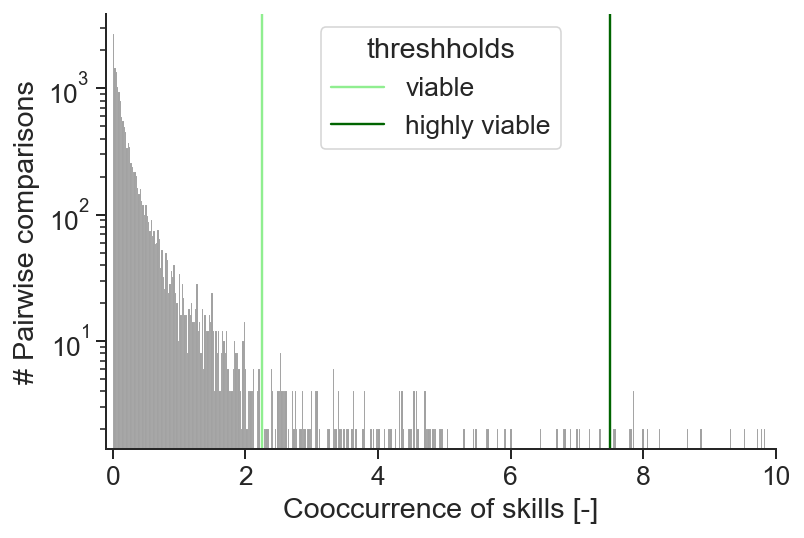

In [10]:
ax = sns.histplot(df_occ_sims.values.flatten(), color="grey", log_scale=(False, True))
ax.set_xlim(-0.1, 10)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Cooccurrence of skills [-]")
plt.legend(loc="upper center", title="threshholds")
sns.despine()

##### Plot occ sim matrix at ISCO 3 digit level

<AxesSubplot:xlabel='Target occupations (isco_3_digit)', ylabel='Source occupations (isco_3_digit)'>

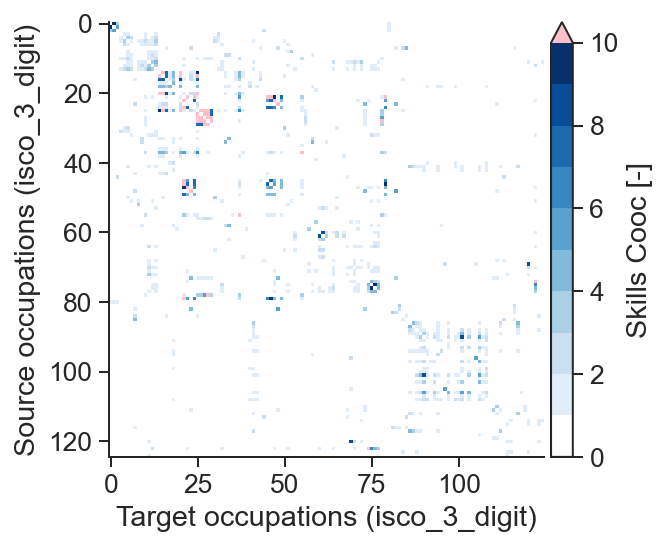

In [11]:
rp.plot_sim_matrix_at_level(vmax=10, mask_upper=False)

##### Plot occupation similarity matrix classified viable/highly viable

<AxesSubplot:xlabel='Target occupations (isco_4_digit)', ylabel='Source occupations (isco_4_digit)'>

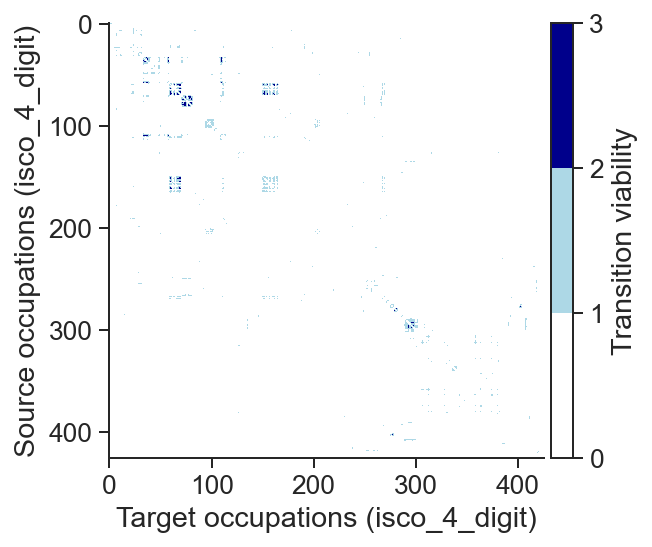

In [12]:
rp.plot_sim_matrix_at_level(level="isco_4_digit", classify=True, mask_upper=False)

#### Transition analysis logic
Base the quantile on the respective quantiles of the viable/highly viable transition categories in the Kanders matrix
- Viable: 96th percentile
- Highly viable: 99th percentile

#### Manually check some transitions

In [13]:
rp.coal_occupations

{'Mining, manufacturing and construction supervisors': '312',
 'Mining and mineral processing plant operators': '811',
 'Manufacturing, mining, construction, and distribution managers': '132',
 'Mining and construction labourers': '931'}

In [14]:
occ = df_occs.loc[
    df_occs.preferredLabel == "Mining and mineral processing plant operators"
]
print(occ.preferredLabel)

transitions = find_closest(
    i=occ.index.values[0], similarity_matrix=similarity_matrix, df=df_occs
)

transitions.head(5)

100    Mining and mineral processing plant operators
Name: preferredLabel, dtype: object


,conceptUri,preferredLabel,code,similarity
90,http://data.europa.eu/esco/isco/C722,"Blacksmiths, toolmakers and related trades wor...",722,1.78
101,http://data.europa.eu/esco/isco/C812,Metal processing and finishing plant operators,812,1.72
106,http://data.europa.eu/esco/isco/C817,Wood processing and papermaking plant operators,817,1.58
103,http://data.europa.eu/esco/isco/C814,"Rubber, plastic and paper products machine ope...",814,1.41
89,http://data.europa.eu/esco/isco/C721,"Sheet and structural metal workers, moulders a...",721,1.08


##### Check the skills distribution at the ISCO 3-digit level

<AxesSubplot:ylabel='Frequency'>

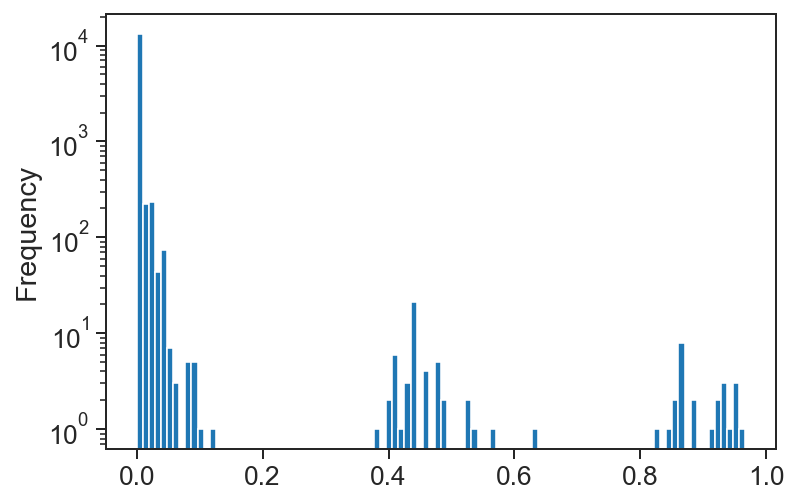

In [15]:
rp.occ_skills_mat_3d.iloc[25, :].plot.hist(bins=100, logy=True)

### Analyse number of viable transitions

In [16]:
countries = [
    "AT",
    "BE",
    "CH",
    #"CY",
    "CZ",
    "DE",
    "DK",
    #"EE",
    "ES",
    "FI",
    "FR",
    "GR",
    "HR",
    "HU",
    "IE",
    "IS",
    "IT",
    "LT",
    #"LU",
    "LV",
    "NL",
    "NO",
    "PT",
    "RO",
    "SE",
    "SK",
    "UK",
]

In [17]:
# modelling settings
scenarios = ["coal"]
upskilling_modes = [
    None
]  # , "random", "computer_literacy", "coreness_weighted", "coreness_percentile", "optimal"]
optimise = "wage"

# thresholds used for first set of results. Lower than the percentile-based thresholds.
transition_thresholds = 1.616368047779022, 6.500853535353546

# results storage
results_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation_test")

In [18]:
simulation_results = rp.simulate(
    level="isco_3_digit",
    countries=countries,
    scenarios=["coal"],
    transition_optimisation=optimise,
    reskilling=None,
    mask_diagonal=True,
    transition_thresholds=transition_thresholds,
    out_dir=results_dir,
)

scenario: coal


In [19]:
rp.visualise_simulation_results_eu(
    simulation_results=simulation_results,
    transition_optimisation="wage",
    version="baseline",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=results_dir,
)

<Figure size 720x360 with 0 Axes>

<Figure size 720x360 with 0 Axes>

##### Create visualisation

In [20]:
# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=None,
    transition_optimisation="wage",
    version="baseline",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=results_dir,
)

<Figure size 720x360 with 0 Axes>

<Figure size 720x360 with 0 Axes>

#### Scenario 2b) Wage continuity + regional constraint

##### Regional distribution of unique occupations
Needed for regional reskilling constraint.

In Germany, over 90% of all unique 3-digit occupations have COEFF > 0 in each NUTS2 region

In [21]:
countries = [
    "AT",
    "BE",
    "CH",
    #"CY",
    "CZ",
    "DE",
    "DK",
    #"EE",
    "ES",
    "FI",
    "FR",
    "GR",
    "HR",
    "HU",
    "IE",
    "IS",
    "IT",
    "LT",
    #"LU",
    #"LV",
    #"NL",
    "NO",
    "PT",
    "RO",
    "SE",
    "SK",
    "UK",
]

##### Fraction based employment availability

In [31]:
rp.jobs_by_country_and_region()

,NUTS_ID,ISCO3D,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRYW,COEFF_share_target_sl,COEFF_share_target_slt
0,AT11,100,0.00,0.00,0.00,0.00,0.00,0.00,AT,0.00,0.00
1,AT11,110,0.00,0.00,0.00,0.00,0.00,0.00,AT,0.00,0.00
2,AT11,111,811.00,0.00,0.00,0.00,811.00,811.00,AT,811.00,811.00
3,AT11,112,711.00,0.00,0.00,0.00,711.00,711.00,AT,711.00,711.00
4,AT11,120,0.00,0.00,0.00,0.00,0.00,0.00,AT,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
37345,UKN,951,0.00,0.00,0.00,0.00,0.00,0.00,UK,0.00,0.00
37346,UKN,952,686.00,0.00,0.00,0.00,686.00,686.00,UK,686.00,686.00
37347,UKN,960,0.00,0.00,0.00,0.00,0.00,0.00,UK,0.00,0.00
37348,UKN,961,"1,646.00",0.00,0.00,"1,234.00",412.00,412.00,UK,"1,646.00","1,646.00"


##### Empirical employment availability

In [131]:
jobs_by_countries_regions = pd.read_pickle(
    os.path.join(config["paths"]["processed"], "lfs_employment_fluctuations_abs_1998_2019.pkl")
)

jobs_by_countries_regions.loc[jobs_by_countries_regions["NUTS_ID"] == "DE93"]

,COUNTRYW,REGIONW,ISCO3D,COEFF_min,COEFF_max,COEFF_mean,COEFF_std,COEFF_median,COEFF_mean+sd,COEFF_2019,NUTS_ID,preferredLabel
0,DE,93,011,0.00,0.00,0.00,0.00,0.00,0.00,0.00,DE93,Commissioned armed forces officers
1,DE,93,021,0.00,0.00,0.00,0.00,0.00,0.00,0.00,DE93,Non-commissioned armed forces officers
2,DE,93,031,0.00,0.00,0.00,0.00,0.00,0.00,0.00,DE93,"Armed forces occupations, other ranks"
3,DE,93,111,30.84,278.83,119.15,138.54,47.78,257.69,455.80,DE93,Legislators and senior officials
4,DE,93,112,19.86,"2,100.11","1,010.51",725.56,"1,062.62","1,736.07","9,985.18",DE93,Managing directors and chief executives
...,...,...,...,...,...,...,...,...,...,...,...,...
120,DE,93,941,478.49,"3,531.16","1,520.29","1,248.85","1,277.76","2,769.14","8,934.94",DE93,Food preparation assistants
121,DE,93,951,0.00,0.00,0.00,0.00,0.00,0.00,0.00,DE93,Street and related service workers
122,DE,93,952,0.00,0.00,0.00,0.00,0.00,0.00,0.00,DE93,Street vendors (excluding food)
123,DE,93,961,120.36,655.79,393.73,267.89,405.05,661.62,"1,019.66",DE93,Refuse workers


##### Simulate (old function)

Viability thresholds: 2.25 7.5
scenario: coal


100%|██████████| 22/22 [00:13<00:00,  1.65it/s]


CPU times: total: 19.4 s
Wall time: 19.8 s


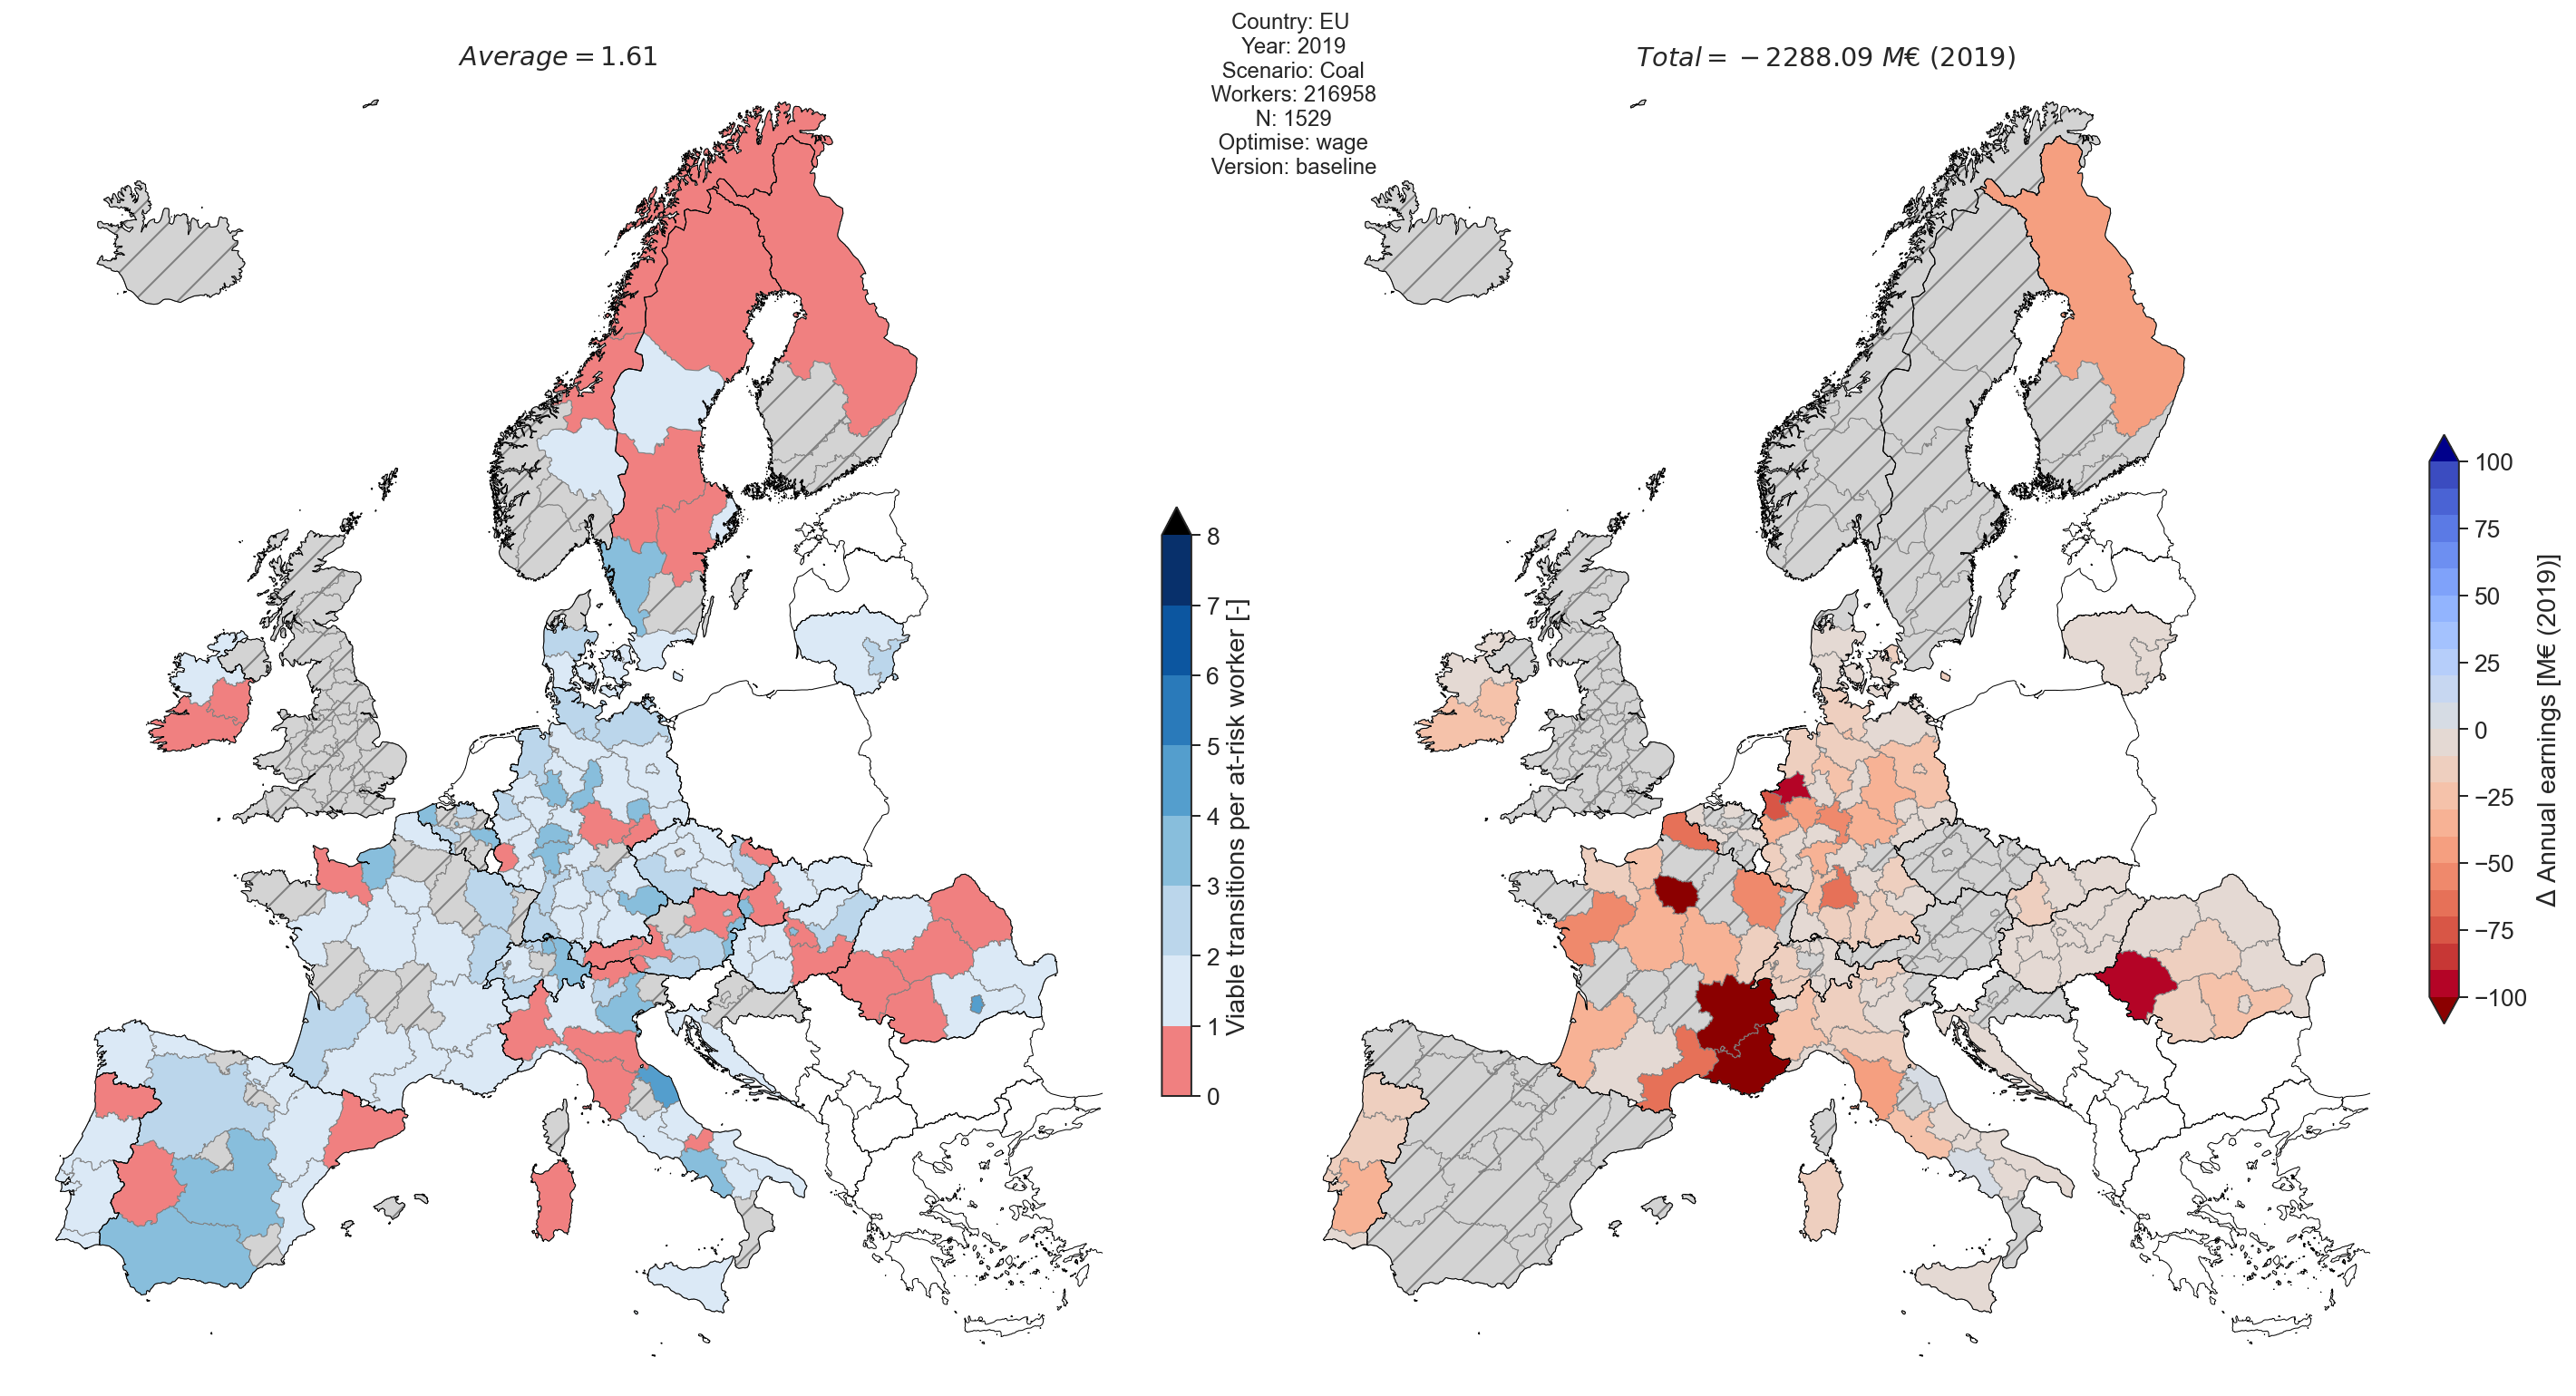

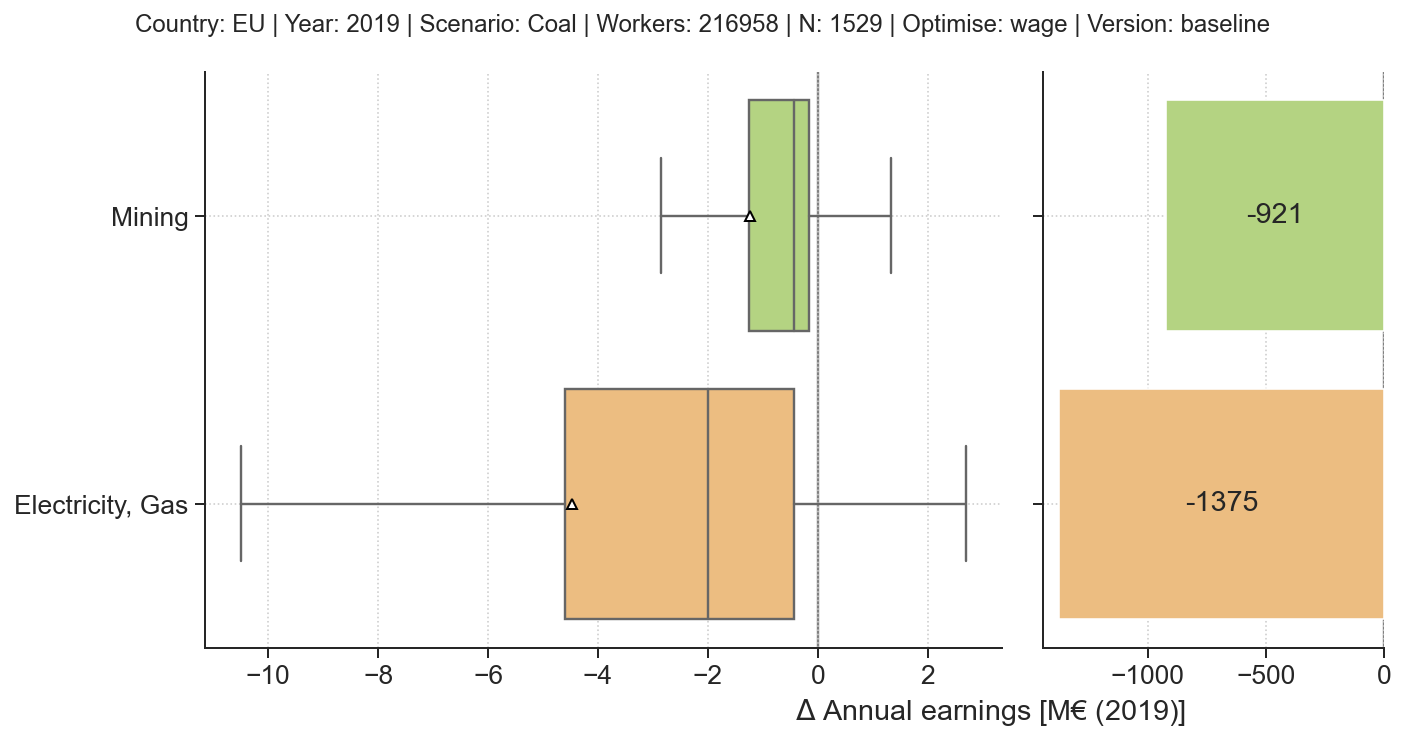

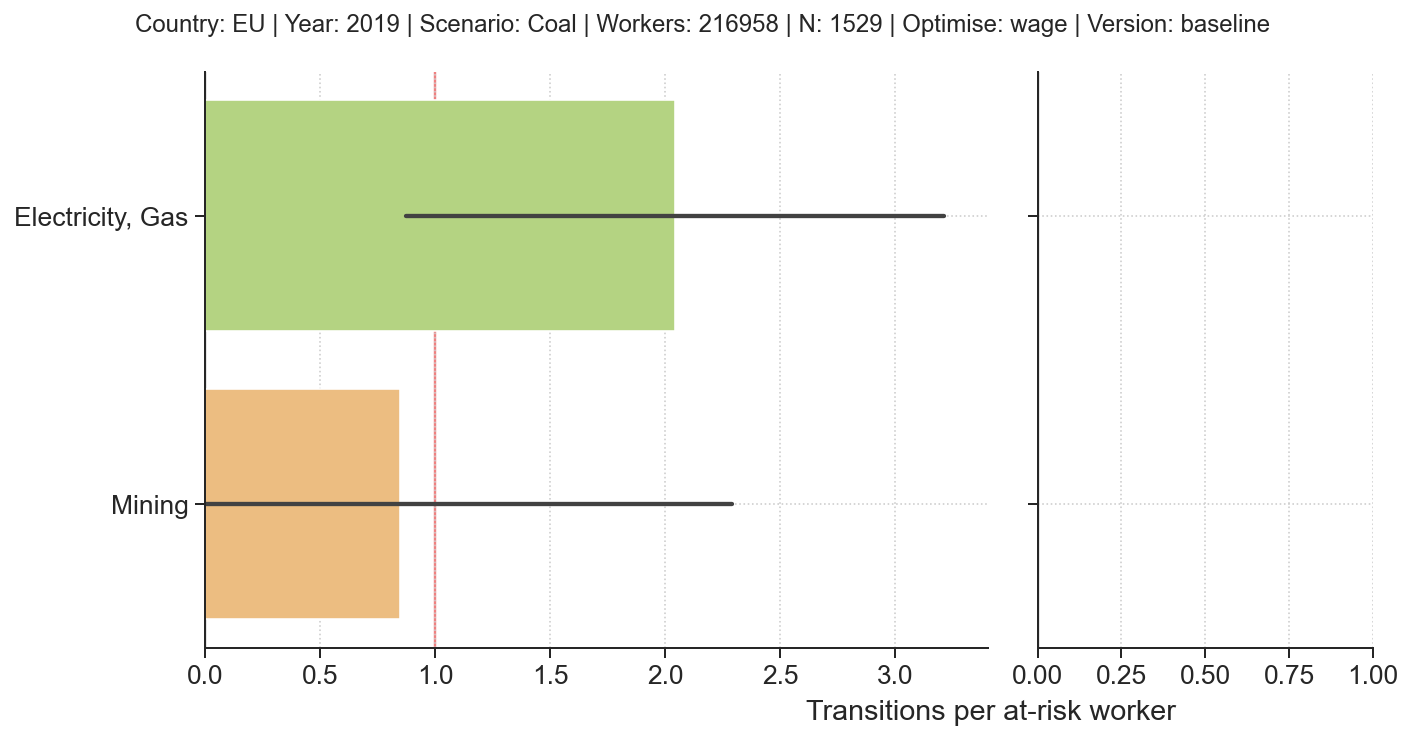

In [156]:
%%time
out_dir = "reskilling_simulation_test"
baseline_results = rp.simulate(
    countries=countries,
    scenarios=["coal"],
    transition_optimisation="wage",
    transition_thresholds=None,
    reskilling=None,
    out_dir=os.path.join(useful_paths.figure_dir, out_dir),
    verbose=False
)

# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=baseline_results,
    transition_optimisation="wage",
    version="baseline",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=os.path.join(useful_paths.figure_dir, out_dir),
    show_plots=True,
    title_fontsize="small",
    cbar_fraction=0.025
)

In [213]:
rp.lfs_data.loc[rp.lfs_data.REGIONW.isna()]

,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRY,COUNTRYW,DEGURBA,...,category_slt,country,country_code,decile,isco_code,share_brown_sl,share_brown_slt,share_green,share_neutral_sl,share_neutral_slt
87611,32,134.99,0.00,0.00,0.00,134.99,134.99,BE,BE,3,...,neutral,Belgium,BE,2.00,522,0.00,0.00,0.00,1.00,1.00
89324,37,115.31,0.00,0.00,0.00,115.31,115.31,BE,BE,2,...,neutral,Belgium,BE,7.00,265,0.00,0.00,0.00,1.00,1.00
100280,52,141.00,0.00,0.00,0.00,141.00,141.00,BE,BE,1,...,neutral,Belgium,BE,10.00,264,0.00,0.00,0.00,1.00,1.00
101348,32,621.19,21.06,10.53,0.00,600.13,610.66,BE,BE,1,...,neutral,Belgium,BE,9.00,132,0.03,0.02,0.00,0.97,0.98
103963,52,197.66,0.00,0.00,0.00,197.66,197.66,BE,BE,1,...,neutral,Belgium,BE,2.00,265,0.00,0.00,0.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411435,57,994.93,0.00,0.00,0.00,994.93,994.93,UK,UK,1,...,neutral,United Kingdom,UK,5.00,532,0.00,0.00,0.00,1.00,1.00
1411438,27,711.91,0.00,0.00,0.00,711.91,711.91,UK,UK,2,...,neutral,United Kingdom,UK,5.00,532,0.00,0.00,0.00,1.00,1.00
1411507,62,913.28,0.00,0.00,0.00,913.28,913.28,UK,UK,1,...,neutral,NaN,NaN,NaN,711,0.00,0.00,0.00,1.00,1.00
1411571,52,782.52,0.00,0.00,89.43,693.09,693.09,UK,UK,2,...,neutral,United Kingdom,UK,10.00,325,0.00,0.00,0.11,0.89,0.89


##### Simulate

In [306]:
%%time
out_dir = "reskilling_simulation_v2_reg"
baseline_results = rp.simulate_regional(
    countries=countries,
    scenarios=["coal"],
    target_job_availability_coeff="COEFF_mean+sd",
    transition_thresholds=None, # (1.616368047779022, 6.500853535353546)
    reskilling=None,
    region_constraints=True,
    out_dir=os.path.join(useful_paths.figure_dir, out_dir),
    verbose=False
)

# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=baseline_results,
    transition_optimisation="wage",
    version="baseline_reg",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=os.path.join(useful_paths.figure_dir, out_dir),
    show_plots=True,
    title_fontsize="small",
    cbar_fraction=0.025
)

Viability thresholds: 2.25 7.5
scenario: coal


  0%|          | 0/8 [00:00<?, ?it/s]

AT AT11
    COUNTRYW REGIONW ISCO3D  COEFF_min  COEFF_max  COEFF_mean  COEFF_std  \
0         AT      11    011       0.00       0.00        0.00       0.00   
1         AT      11    021       0.00       0.00        0.00       0.00   
2         AT      11    031       0.00       0.00        0.00       0.00   
3         AT      11    111       3.00     508.00      171.00     197.00   
4         AT      11    112      33.00     528.00      161.00     186.00   
..       ...     ...    ...        ...        ...         ...        ...   
120       AT      11    941      56.00     345.00      206.00     119.00   
121       AT      11    951       0.00       0.00        0.00       0.00   
122       AT      11    952       0.00       0.00        0.00       0.00   
123       AT      11    961      15.00     195.00       98.00      76.00   
124       AT      11    962      75.00     194.00      150.00      55.00   

     COEFF_median  COEFF_mean+sd  COEFF_2019 NUTS_ID  
0            0.00       

 25%|██▌       | 2/8 [00:00<00:00, 13.20it/s]


AT AT11
    COUNTRYW REGIONW ISCO3D  COEFF_min  COEFF_max  COEFF_mean  COEFF_std  \
0         AT      11    011       0.00       0.00        0.00       0.00   
1         AT      11    021       0.00       0.00        0.00       0.00   
2         AT      11    031       0.00       0.00        0.00       0.00   
3         AT      11    111       3.00     508.00      171.00     197.00   
4         AT      11    112      33.00     528.00      161.00     186.00   
..       ...     ...    ...        ...        ...         ...        ...   
120       AT      11    941      56.00     345.00      206.00     119.00   
121       AT      11    951       0.00       0.00        0.00       0.00   
122       AT      11    952       0.00       0.00        0.00       0.00   
123       AT      11    961      15.00     195.00       98.00      76.00   
124       AT      11    962      75.00     194.00      150.00      55.00   

     COEFF_median  COEFF_mean+sd  COEFF_2019 NUTS_ID  
0            0.00      

...

100%|██████████| 3/3 [00:00<00:00,  7.38it/s]

IE IE05
    COUNTRYW REGIONW ISCO3D  COEFF_min  COEFF_max  COEFF_mean  COEFF_std  \
0         IE      05    011       0.00       0.00        0.00       0.00   
1         IE      05    021       0.00       0.00        0.00       0.00   
2         IE      05    031       0.00       0.00        0.00       0.00   
3         IE      05    111      41.00     122.00       80.00      41.00   
4         IE      05    112      69.00   1,079.00      359.00     482.00   
..       ...     ...    ...        ...        ...         ...        ...   
120       IE      05    941     712.00   2,996.00    1,942.00   1,073.00   
121       IE      05    951      14.00     119.00       46.00      49.00   
122       IE      05    952       8.00      48.00       32.00      22.00   
123       IE      05    961     104.00     306.00      211.00     102.00   
124       IE      05    962     479.00     760.00      620.00     199.00   

     COEFF_median  COEFF_mean+sd  COEFF_2019 NUTS_ID  
0            0.00       


  0%|          | 0/1 [00:00<?, ?it/s]

IS IS99
Empty DataFrame
Columns: [COUNTRYW, REGIONW, ISCO3D, COEFF_min, COEFF_max, COEFF_mean, COEFF_std, COEFF_median, COEFF_mean+sd, COEFF_2019, NUTS_ID]
Index: []
conceptUri           http://data.europa.eu/esco/isco/C333
preferredLabel                   Business services agents
code                                                  333
share_green                                          0.00
share_brown_sl                                       0.00
share_brown_slt                                      0.00
share_neutral_sl                                     1.00
share_neutral_slt                                    1.00
INCDECIL_imputed                                      NaN
annual_earnings                                       NaN
category_sl                                       neutral
category_slt                                      neutral
similarity                                           3.25
COUNTRYW                                              NaN
REGIONW               

IndexError: index 0 is out of bounds for axis 0 with size 0

In [200]:
baseline_results["coal"]["AT"]["annual_earnings"].isna().all()

True

In [210]:
jobs_by_regions_countries = pd.read_pickle(
            os.path.join(
                "C:", os.sep, "eurostat_data", "processed",
                "lfs_employment_fluctuations_abs_1998_2019.pkl"
            )
        )
jobs_by_regions_countries

,COUNTRYW,REGIONW,ISCO3D,COEFF_min,COEFF_max,COEFF_mean,COEFF_std,COEFF_median,COEFF_mean+sd,COEFF_2019,NUTS_ID
0,AT,11,011,0.00,0.00,0.00,0.00,0.00,0.00,0.00,AT11
1,AT,11,021,0.00,0.00,0.00,0.00,0.00,0.00,0.00,AT11
2,AT,11,031,0.00,0.00,0.00,0.00,0.00,0.00,0.00,AT11
3,AT,11,111,2.82,507.13,170.16,196.88,119.37,367.04,810.03,AT11
4,AT,11,112,32.60,527.82,160.63,185.93,111.09,346.56,710.01,AT11
...,...,...,...,...,...,...,...,...,...,...,...
120,UK,N0,941,435.14,"3,601.96","2,599.94","1,493.17","3,181.33","4,093.11","10,463.72",UKN0
121,UK,N0,951,0.00,0.00,0.00,0.00,0.00,0.00,0.00,UKN0
122,UK,N0,952,121.01,"1,312.92",960.03,563.93,"1,203.10","1,523.97",685.29,UKN0
123,UK,N0,961,290.74,"1,872.59","1,081.66","1,118.54","1,081.66","2,200.20","1,645.21",UKN0


Viability thresholds: 2.25 7.5
scenario: coal


100%|██████████| 11/11 [00:03<00:00,  2.76it/s]
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\numpy\lib\nanfunctions.py:1117: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\numpy\lib\nanfunctions.py:1117: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


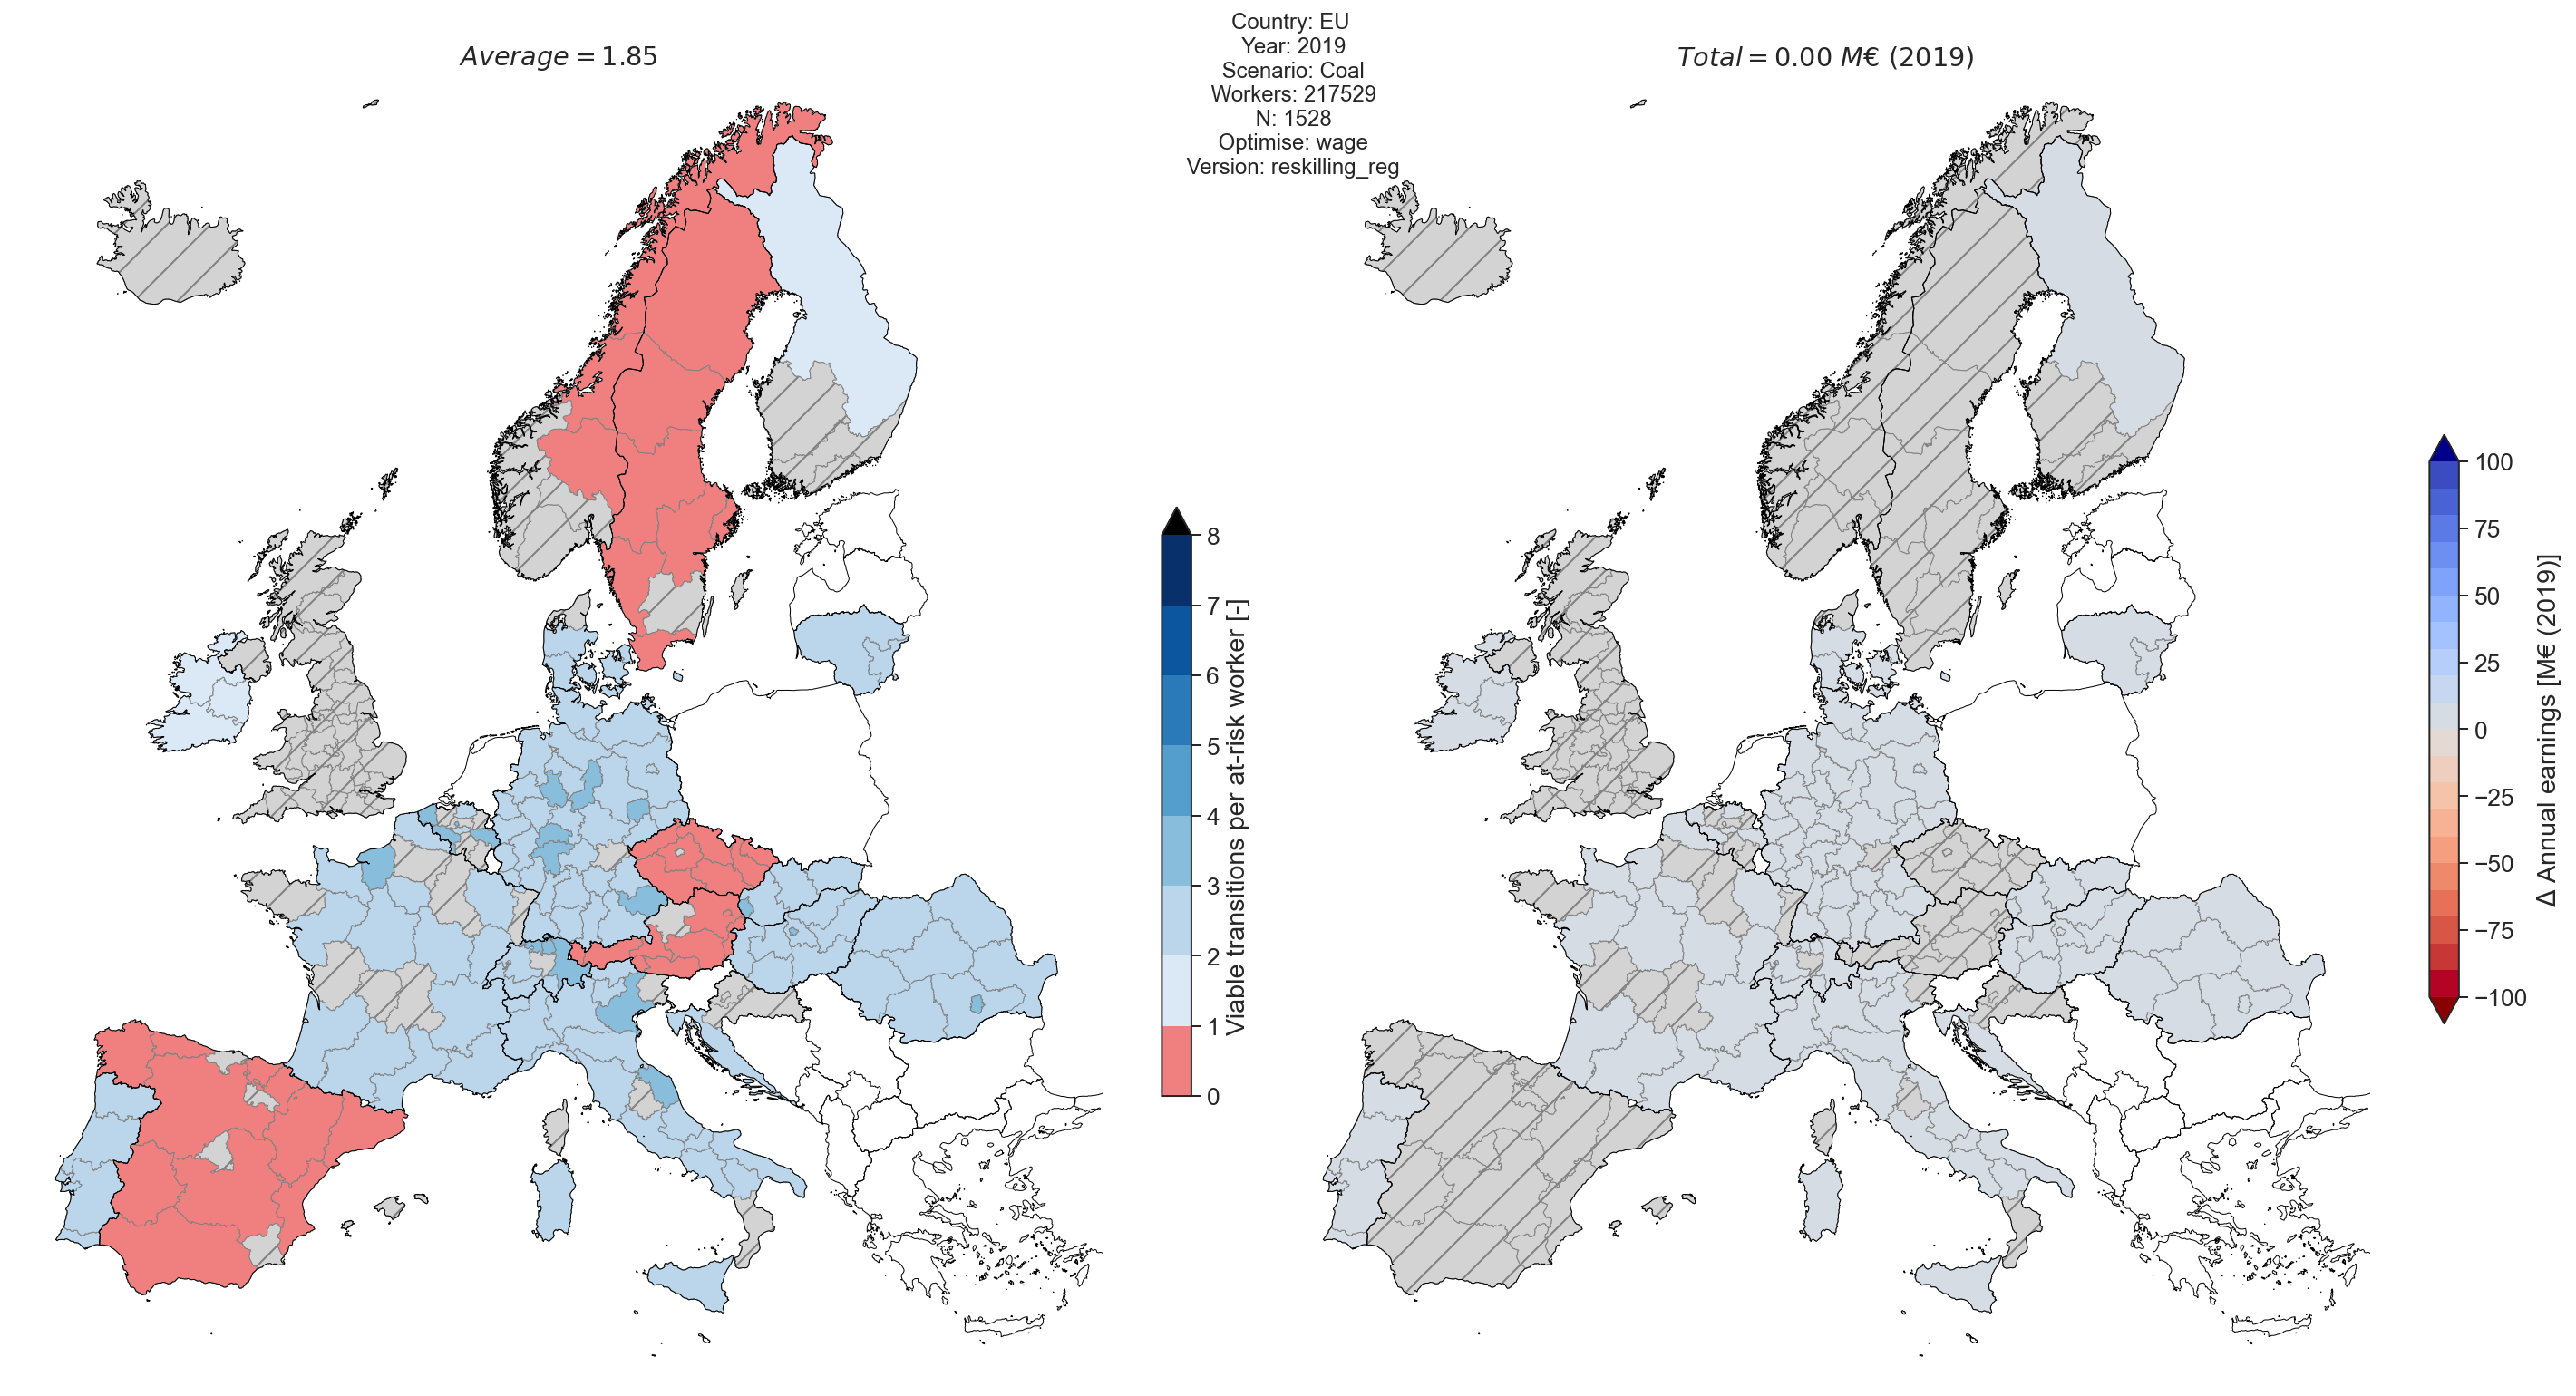

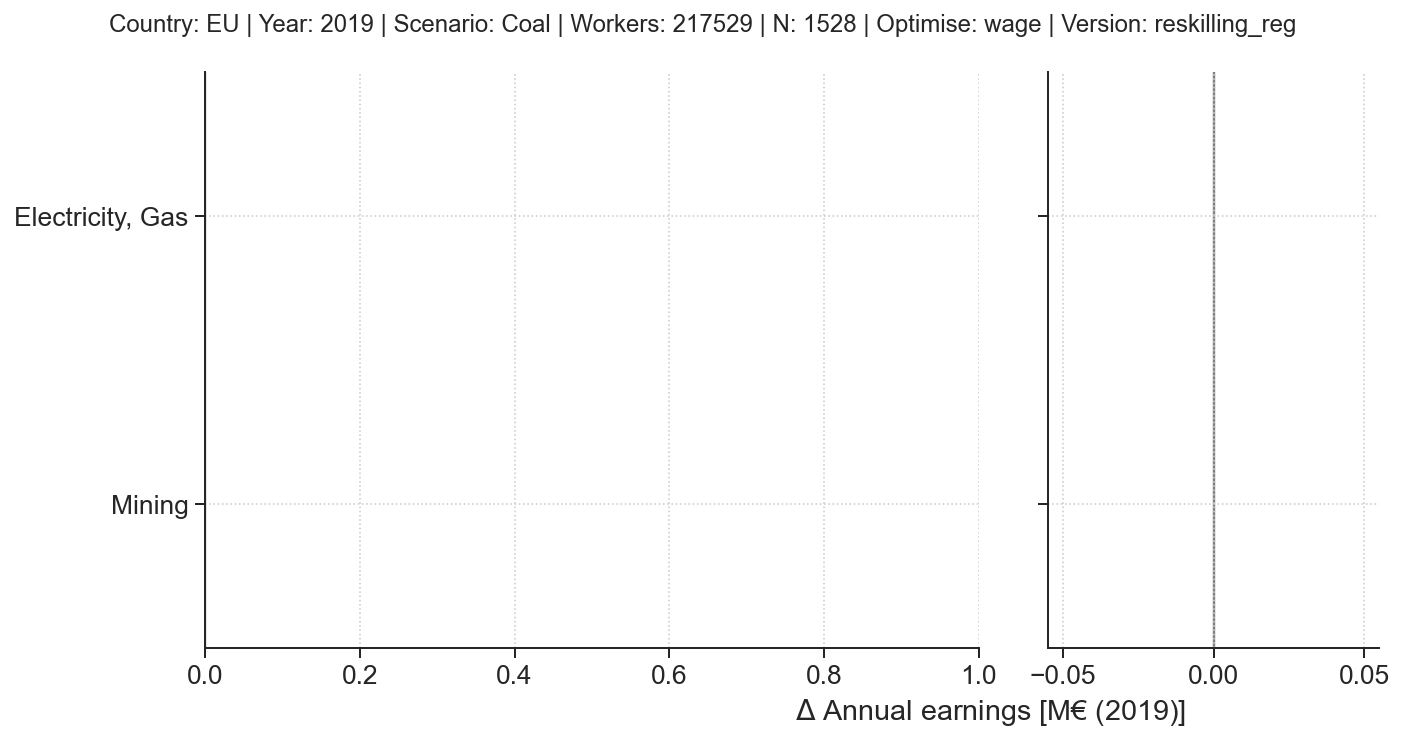

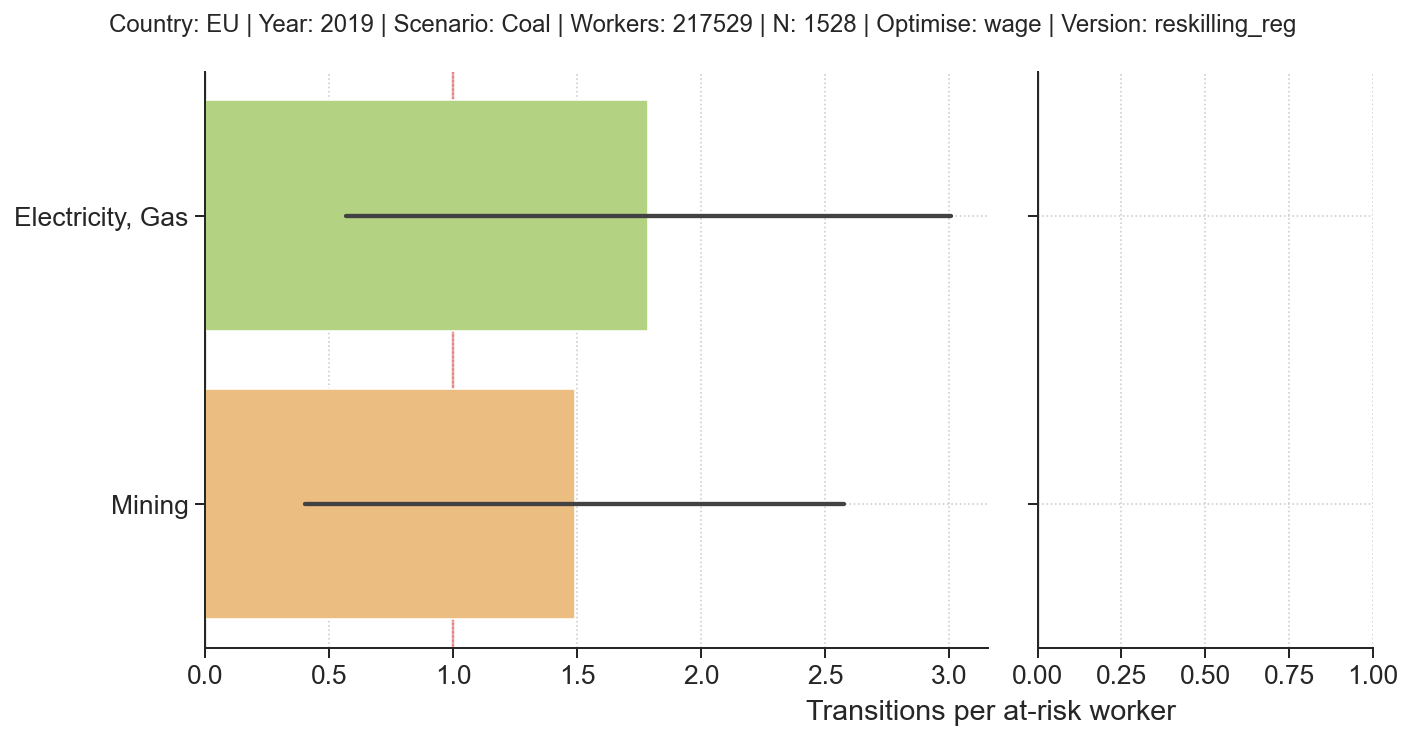

In [147]:
reskilling_results = rp.simulate_regional(
    countries=countries,
    scenarios=["coal"],
    target_job_availability_coeff="COEFF_mean+sd",
    transition_thresholds=None,
    reskilling="optimal",
    region_constraints=False,
    out_dir=os.path.join(useful_paths.figure_dir, out_dir),
    verbose=False
)

# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=reskilling_results,
    transition_optimisation="wage",
    version="reskilling_reg",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=os.path.join(useful_paths.figure_dir, out_dir),
    show_plots=True,
    title_fontsize="small",
    cbar_fraction=0.025
)

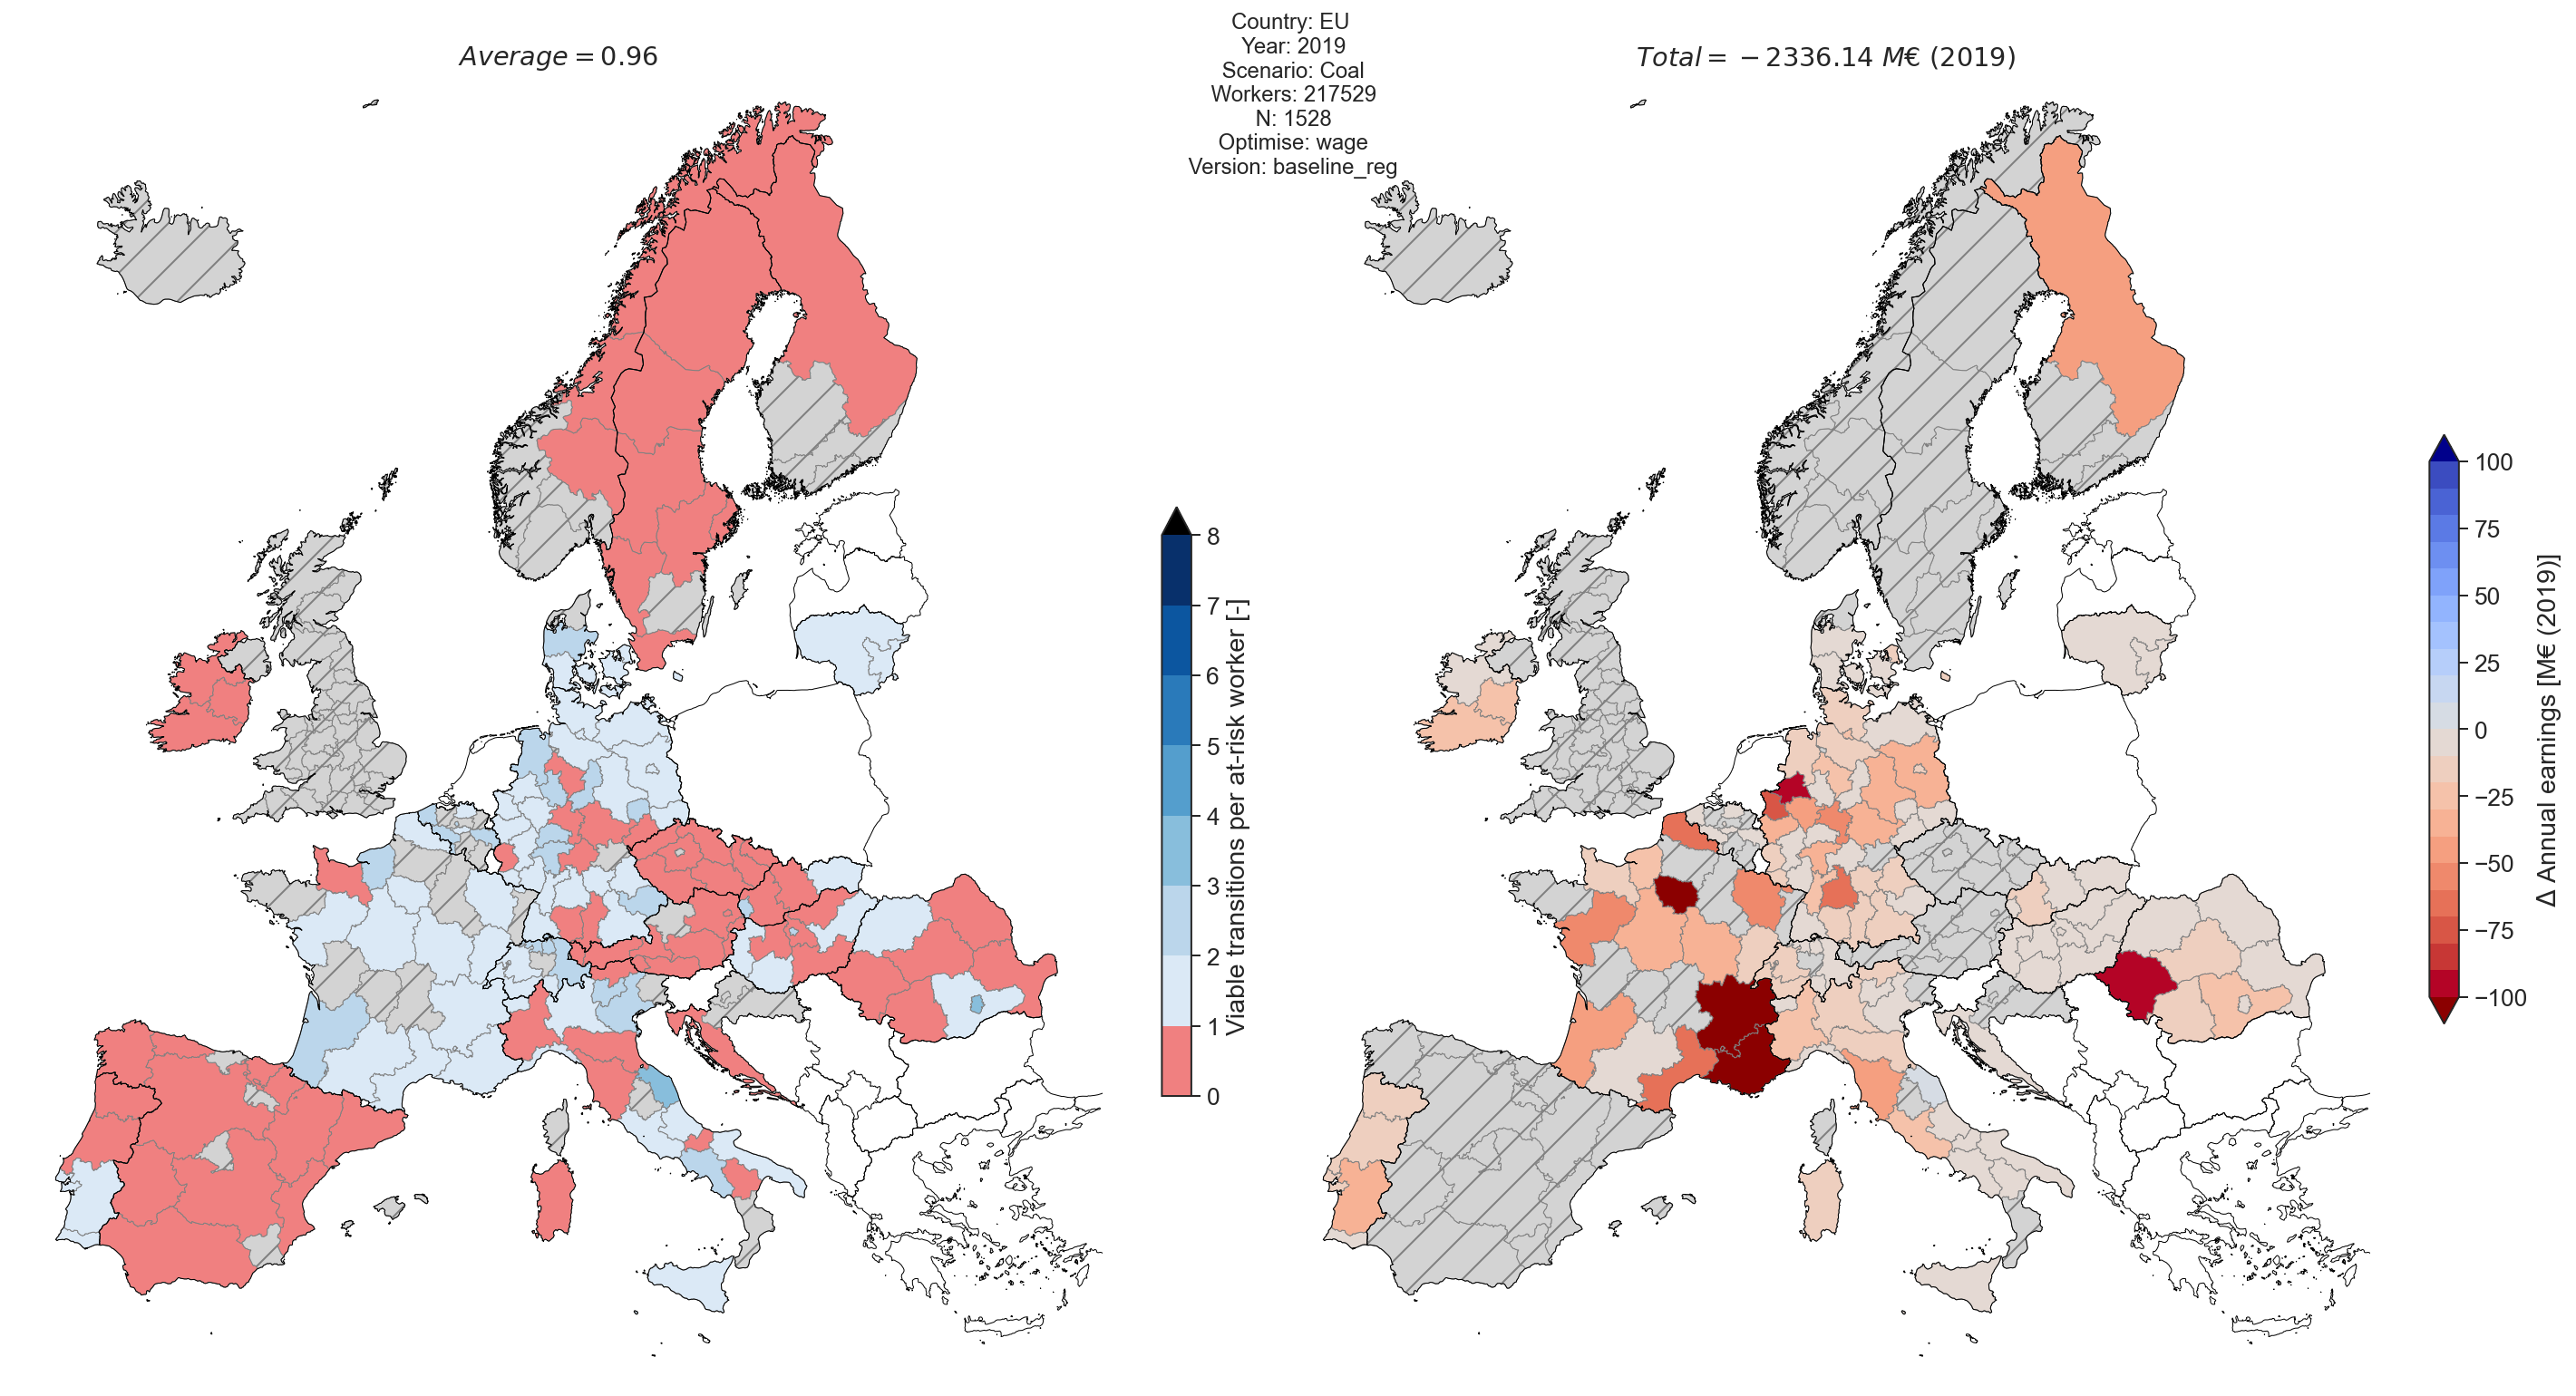

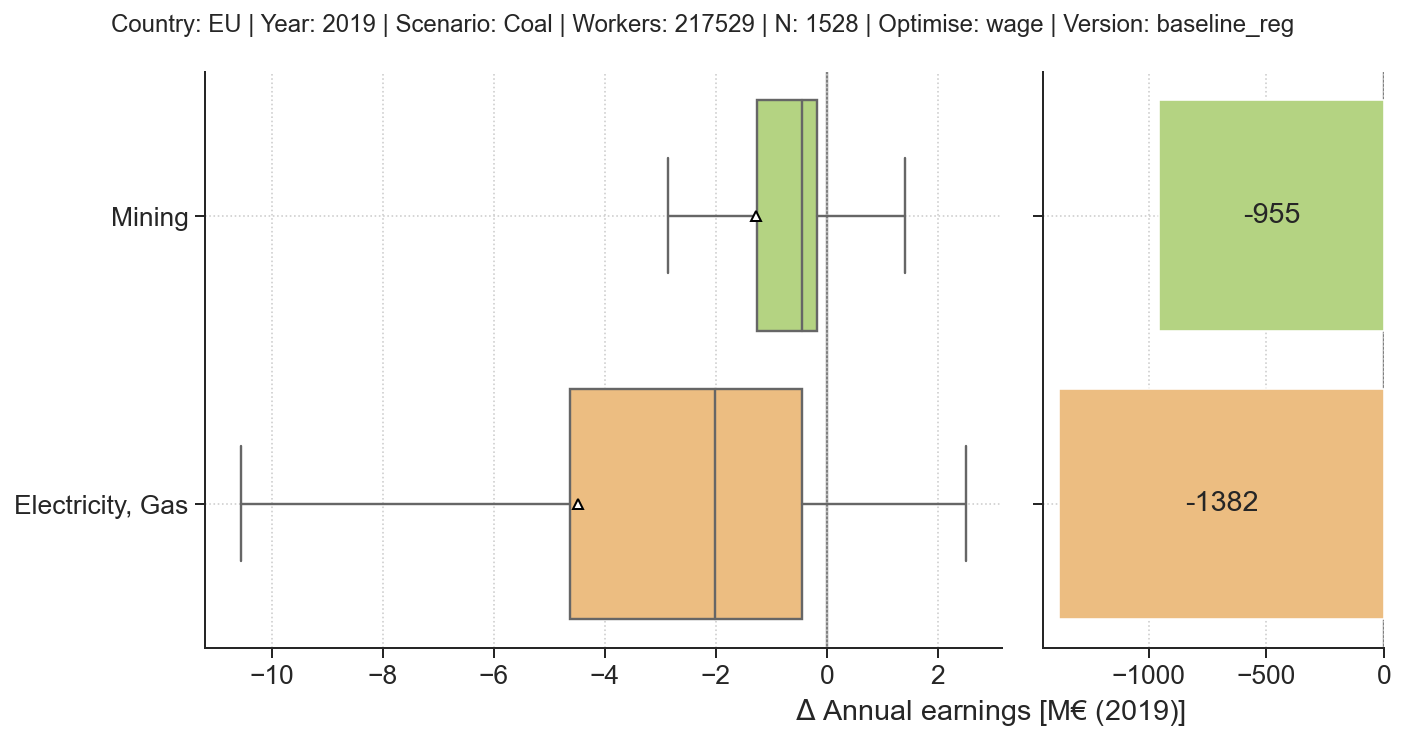

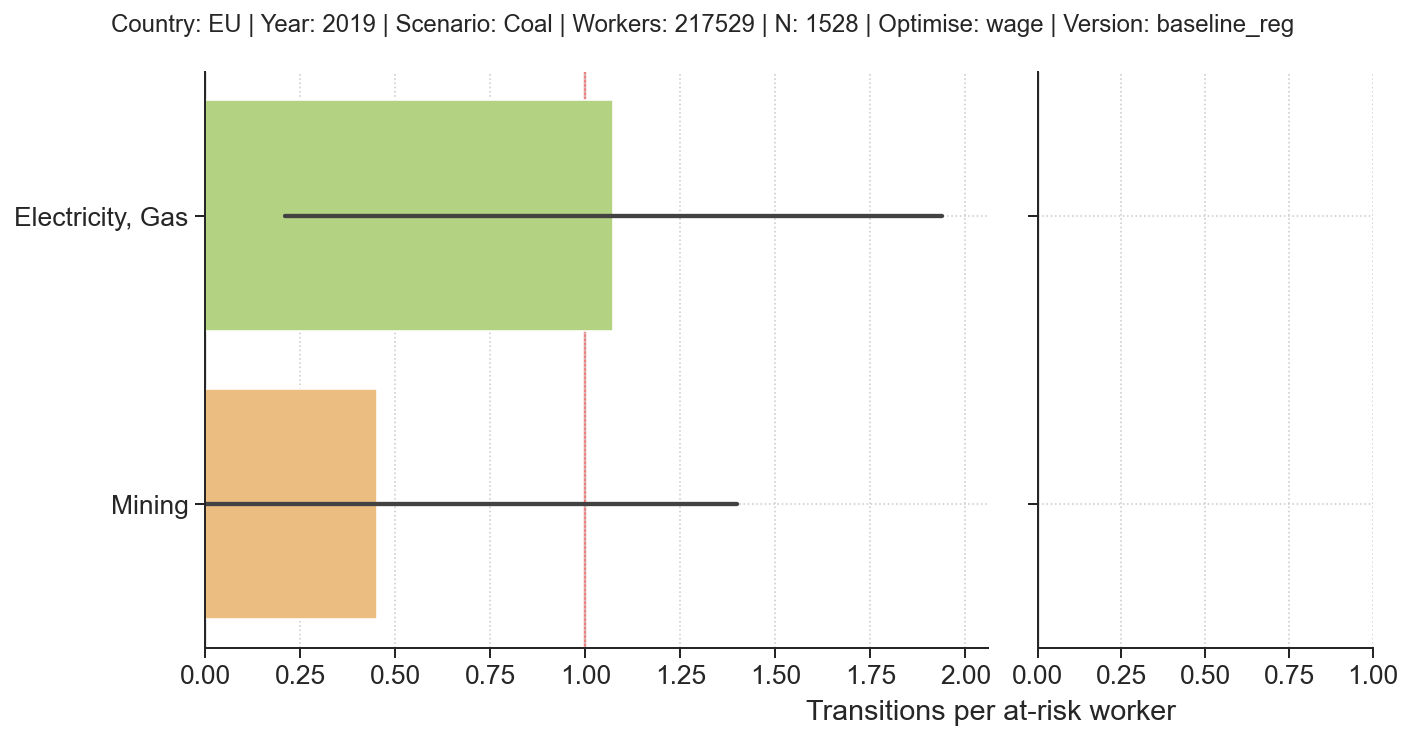

##### Regional availability of jobs after transitions
- How many percent of available jobs were filled by transitioning workers?
- How many jobs remain (as a percentage of the original number)?

In [23]:
assert 1 == 2

AssertionError: 

## Upskilling analysis
- use stylised results from the upskilling analyis
- add skills that were found to unlock the most additional viable transitions per occupation to profile before calculating transitions
- pre-compute 4 different similarity matrices where those skills are already added

In [ ]:
df_top_skills_per_occ = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_best_5_skills_per_isco3d_occupation.csv",
    ),
    index_col=0,
)

df_top_skills_per_occ

if two skills unlock the same (top) number of new viable transitions, choose the one with the higher coreness

In [ ]:
isco_groups = esco.isco_groups
isco_groups_3d = isco_groups[isco_groups.code.str.len() == 3]
isco_group_dict = dict(zip(isco_groups_3d.preferredLabel, isco_groups_3d.code))

In [ ]:
optimal_upskilling_per_occ = []
for group, df in df_top_skills_per_occ.groupby("Occupation"):
    # max new viable transitions
    t_max = df["Viable transitions"].max()
    sub_df = df[df["Viable transitions"] == t_max]

    # max coreness if multiple options
    c_max = sub_df["Coreness"].max()
    sub_sub_df = sub_df[sub_df["Coreness"] == c_max]
    optimal_upskilling_per_occ.append(sub_sub_df)

df_optimal_upskilling_per_occ = pd.concat(
    optimal_upskilling_per_occ, axis=0
).reset_index(drop=True)

# get skill id
# todo: refactor to point to MCC repository
coreness = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.csv"),
    index_col=0,
)

df_optimal_upskilling_per_occ = pd.merge(
    df_optimal_upskilling_per_occ,
    coreness.reset_index()[["index", "preferredLabel"]].rename(
        columns={"preferredLabel": "Skill", "index": "id_skill"}
    ),
    on="Skill",
)

df_optimal_upskilling_per_occ["id_occ"] = [
    isco_group_dict[occ_label]
    for occ_label in df_optimal_upskilling_per_occ.Occupation.values
]

df_optimal_upskilling_per_occ.to_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_selected_skill_per_occupation.csv",
    )
)
df_optimal_upskilling_per_occ

In [ ]:
occ_sims_isco3 = df_occ_sims.values
np.fill_diagonal(occ_sims_isco3, 0)

In [ ]:
occ_codes = rp.get_occs()
occ_codes

In [ ]:
from src.modelling.occupation_distance import occ_sim_matrix_by_levels

occ = df_optimal_upskilling_per_occ.iloc[0]
occ_sim_matrix_by_levels(upskilling_ids=(occ.id_occ, occ.id_skill))

In [ ]:
occ = df_optimal_upskilling_per_occ.iloc[0]
print(occ)

# find index of occ
idx_occ = occ_codes[occ_codes.code == occ.id_occ].index.values[0]
idx_new_skill = occ.id_skill
print(idx_occ, idx_new_skill)

# add skill to occ skill profile
occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

# recalc occ sim matrix
occ_sims_isco3_upskilling = np.matmul(
    occ_skills_mat_isco3_upskilling.values,
    occ_skills_mat_isco3_upskilling.values.transpose(),
)
np.fill_diagonal(occ_sims_isco3_upskilling, 0)

In [ ]:
rp.get_occs()

#### 1) Skills continuity scenario with upskilling

In [ ]:
%%time
if run_skills_continuity_scenarios:
    transition_number_data = []

    for i, src_worker in tqdm(df_transition_pool.iterrows()):

        search_label = src_worker.ISCO3D_label
        idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

        # -----------------------------------------------------------------------------------------------------------------------------
        # UPSKILLING STEP
        # -----------------------------------------------------------------------------------------------------------------------------
        # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
        upskilling_data = df_optimal_upskilling_per_occ.loc[
            df_optimal_upskilling_per_occ.Occupation == search_label
        ]

        # find index of occ
        idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
        idx_new_skill = upskilling_data.id_skill

        # add skill to occ skill profile
        occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
        occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

        # recalc occ sim matrix
        occ_sims_isco3_upskilling = np.matmul(
            occ_skills_mat_isco3_upskilling.values,
            occ_skills_mat_isco3_upskilling.values.transpose(),
        )
        np.fill_diagonal(occ_sims_isco3_upskilling, 0)

        # find closest transitions
        target_occs = find_closest(
            i=idx, similarity_matrix=occ_sims_isco3_upskilling, df=df_occs
        )

        # filter
        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
        target_occs_filtered = target_occs_filtered.loc[
            target_occs_filtered.category != "brown"
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # earnings delta to next closest occupation
        target = target_occs_filtered.head(1)

        # check if viable transition exists
        if not target.empty:
            # Every worker transitions to the next-closest job and I evaluate the wage difference
            src_worker["earnings_delta_closest_switch"] = (
                target.annual_earnings_2016.values[0] - src_worker.annual_earnings_2016
            )
            src_worker["earnings_delta_closest_switch_sum"] = (
                target.annual_earnings_2016.values[0] - src_worker.annual_earnings_2016
            ) * src_worker[transition_pool_weights]
            src_worker["n_viable_transitions"] = target_occs_filtered.shape[0]
            src_worker["n_viable_transitions_sum"] = (
                target_occs_filtered.shape[0] * src_worker[transition_pool_weights]
            )
            src_worker["transition_viable"] = True
            src_worker["transition_target"] = target.occ.values[0]
            src_worker["target_category"] = target.category.values[0]
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            src_worker[
                "earnings_delta_closest_switch"
            ] = src_worker.annual_earnings_2016 * (-1)
            src_worker["earnings_delta_closest_switch_sum"] = (
                src_worker.annual_earnings_2016
                * (-1)
                * src_worker[transition_pool_weights]
            )
            src_worker["n_viable_transitions"] = 0
            src_worker["n_viable_transitions_sum"] = 0
            src_worker["transition_viable"] = False
            src_worker["transition_target"] = None
            src_worker["target_category"] = None

        transition_number_data.append(src_worker)

    # to df
    df_transition_numbers = pd.concat(transition_number_data, axis=1).T
    df_transition_numbers = df_transition_numbers.infer_objects()

    # Calculate avg number of transitions per threatened job
    df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
    df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
        df_transition_numbers_by_nuts.n_viable_transitions_sum
        / df_transition_numbers_by_nuts[transition_pool_weights]
    )

    # to gdf
    gdf_transition_numbers_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        df_transition_numbers_by_nuts.reset_index(),
        on="NUTS_ID",
        how="left",
    )

    # PLOTS

    # TRANSITION NUMBERS
    ax = gdf_transition_numbers_by_nuts.plot(
        column="n_viable_transitions_rel",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        vmin=0,
        vmax=vmax_transitions,
        legend_kwds={
            "label": "Viable transitions per threatened job [-]",
            "fraction": 0.03,
            "extend": "max",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    # ax.set_title("Viable transitions (upskilling)")
    ax.axis("off")

    # EARNINGS LOSSES
    cmap = plt.get_cmap("RdYlGn")
    v = vmax_wages
    gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = (
        gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
    )
    ax = gdf_transition_numbers_by_nuts.plot(
        column="earnings_delta_closest_switch_sum",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_earnings,
        vmin=-v,
        vmax=v,
        legend_kwds={
            "label": "Change in total annual earnings [Mio € in 2010]",
            "fraction": 0.03,
            "extend": "both",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    ax.set_title("Skills continuity scenario (upskilling)")
    ax.axis("off")
    plt.tight_layout()

    # totals
    earnings_losses[
        "skills_continuity_upskilling"
    ] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

    print(
        np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
        / (40 * 10**9)
    )
    gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

### Comparison of earnings losses across scenarios

In [ ]:
df_earnings_losses = pd.DataFrame.from_dict(
    earnings_losses, orient="index", columns=["annual_earnings_delta"]
)
df_earnings_losses.index.name = "scenario"
wage_scenario = df_earnings_losses.reset_index()
wage_scenario["annual_earnings_delta_mio"] = (
    wage_scenario["annual_earnings_delta"] / 10**6
)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.barplot(
    data=wage_scenario,
    x="scenario",
    y="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
)

sns.despine()

ax.set_xlabel(None)
ax.set_ylabel("Change in total annual earnings [M€ (2019)]")

plt.xticks(np.arange(2), ["Before", "After"])
plt.grid(axis="y", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=wage_scenario,
    y="scenario",
    x="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
    orient="h",
)

sns.despine()

ax.set_ylabel(None)
ax.set_xlabel("Change in total annual earnings [M€ (2019)]")

plt.yticks(np.arange(2), ["Before", "After"])
plt.grid(axis="x", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

Pension in Germany with 67 years

In [ ]:
median_age_coal_workers = 52
pension_age = 67
age_delta = pension_age - median_age_coal_workers

wage_scenario["earnings_delta_mio_15yrs"] = (
    wage_scenario.annual_earnings_delta_mio * age_delta
)
wage_scenario